In [1]:
from pathlib import Path
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    classification_report
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from tqdm.auto import tqdm

In [2]:
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True

print("DEVICE:", DEVICE)

DEVICE: cuda


In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [6]:
PROJECT_DIR = Path("/content/drive/MyDrive/Knee_OA_Project")
DATA_DIR = Path("/content/kneeoa_data")

RUN1_DIR = PROJECT_DIR / "experiments" / "resnet50_fullimg256_wce_v1"
RUN2_DIR = PROJECT_DIR / "experiments" / "resnet50_fullimg256_wce_v2"

CKPT1_PATH = RUN1_DIR / "best_model.pt"
CKPT2_PATH = RUN2_DIR / "best_model.pt"

ENSEMBLE_DIR = PROJECT_DIR / "experiments" / "resnet50_ensemble_eval"
ENSEMBLE_DIR.mkdir(parents=True, exist_ok=True)

ENS_PRED_PATH = ENSEMBLE_DIR / "ensemble_predictions.csv"
ENS_CM_PATH = ENSEMBLE_DIR / "ensemble_confusion_matrix.png"
ENS_SUMMARY_PATH = ENSEMBLE_DIR / "ensemble_summary.txt"

print(CKPT1_PATH)
print(CKPT2_PATH)

/content/drive/MyDrive/Knee_OA_Project/experiments/resnet50_fullimg256_wce_v1/best_model.pt
/content/drive/MyDrive/Knee_OA_Project/experiments/resnet50_fullimg256_wce_v2/best_model.pt


In [8]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/Knee_OA_Project")
ZIP_PATH = PROJECT_DIR / "archive (10).zip"

print("ZIP exists:", ZIP_PATH.exists())
print("ZIP path:", ZIP_PATH)

ZIP exists: True
ZIP path: /content/drive/MyDrive/Knee_OA_Project/archive (10).zip


In [9]:
from pathlib import Path
import zipfile
import shutil

DATA_DIR = Path("/content/kneeoa_data")
ZIP_PATH = Path("/content/drive/MyDrive/Knee_OA_Project/archive (10).zip")

# Optional: remove broken partial extraction
if DATA_DIR.exists():
    shutil.rmtree(DATA_DIR)

DATA_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    zf.extractall(DATA_DIR)

print("Extraction complete.")
print("Top-level contents:", [p.name for p in DATA_DIR.iterdir()])

Extraction complete.
Top-level contents: ['auto_test', 'train', 'val', 'test']


In [10]:
from pathlib import Path

DATA_DIR = Path("/content/kneeoa_data")

for p in DATA_DIR.iterdir():
    print(p)

/content/kneeoa_data/auto_test
/content/kneeoa_data/train
/content/kneeoa_data/val
/content/kneeoa_data/test


In [11]:
from pathlib import Path

def find_dataset_root(base_dir: Path):
    candidates = [base_dir] + [p for p in base_dir.rglob("*") if p.is_dir()]
    for c in candidates:
        if (c / "train").exists() and (c / "val").exists() and (c / "test").exists():
            return c
    return None

base_dir = Path("/content/kneeoa_data")
detected_root = find_dataset_root(base_dir)

print("Detected dataset root:", detected_root)

Detected dataset root: /content/kneeoa_data


In [12]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/Knee_OA_Project")
base_extract_dir = Path("/content/kneeoa_data")

def find_dataset_root(base_dir: Path):
    candidates = [base_dir] + [p for p in base_dir.rglob("*") if p.is_dir()]
    for c in candidates:
        if (c / "train").exists() and (c / "val").exists() and (c / "test").exists():
            return c
    return None

DATA_DIR = find_dataset_root(base_extract_dir)

if DATA_DIR is None:
    raise ValueError("Could not find dataset root containing train/val/test. Re-extract the zip and inspect folders.")

print("Using DATA_DIR:", DATA_DIR)
print("Contents:", [p.name for p in DATA_DIR.iterdir()])

Using DATA_DIR: /content/kneeoa_data
Contents: ['auto_test', 'train', 'val', 'test']


In [13]:
CLASS_NAMES = ["0", "1", "2", "3", "4"]
LABEL_MAP = {c: int(c) for c in CLASS_NAMES}
SPLITS = ["train", "val", "test"]
VALID_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

rows = []
for split in SPLITS:
    split_dir = DATA_DIR / split
    if not split_dir.exists():
        print(f"Missing split folder: {split_dir}")
        continue

    for cls in CLASS_NAMES:
        cls_dir = split_dir / cls
        if not cls_dir.exists():
            print(f"Missing class folder: {cls_dir}")
            continue

        for p in cls_dir.rglob("*"):
            if p.is_file() and p.suffix.lower() in VALID_EXTS:
                rows.append({
                    "path": str(p),
                    "label": LABEL_MAP[cls],
                    "split": split
                })

df = pd.DataFrame(rows)

print("Total images found:", len(df))
print(df.groupby(["split", "label"]).size().unstack(fill_value=0))

test_df = df[df["split"] == "test"].reset_index(drop=True)
print("Test size:", len(test_df))

Total images found: 8260
label     0     1     2    3    4
split                            
test    639   296   447  223   51
train  2286  1046  1516  757  173
val     328   153   212  106   27
Test size: 1656


In [15]:
IMG_SIZE = 256
BATCH_SIZE = 32
NUM_WORKERS = 0

In [16]:
class KneeOADataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"])
        img = ImageOps.exif_transpose(img)
        y = int(row["label"])
        return img, y, row["path"]

In [17]:
def pil_collate_fn(batch):
    imgs, labels, paths = zip(*batch)
    labels = torch.tensor(labels, dtype=torch.long)
    return list(imgs), labels, list(paths)

test_loader = DataLoader(
    KneeOADataset(test_df),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=pil_collate_fn
)

print("Number of test batches:", len(test_loader))

Number of test batches: 52


In [18]:
def build_model():
    model = models.resnet50(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, 5)
    )
    return model.to(DEVICE)

model1 = build_model()
model2 = build_model()

ckpt1 = torch.load(CKPT1_PATH, map_location=DEVICE, weights_only=False)
ckpt2 = torch.load(CKPT2_PATH, map_location=DEVICE, weights_only=False)

model1.load_state_dict(ckpt1["model_state_dict"])
model2.load_state_dict(ckpt2["model_state_dict"])

model1.eval()
model2.eval()

print("Loaded model 1 from epoch:", ckpt1["epoch"])
print("Loaded model 2 from epoch:", ckpt2["epoch"])

Loaded model 1 from epoch: 7
Loaded model 2 from epoch: 3


In [19]:
def tfm_original(img):
    return transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225]),
    ])(img)

def tfm_hflip(img):
    img = transforms.Grayscale(num_output_channels=3)(img)
    img = transforms.Resize((IMG_SIZE, IMG_SIZE))(img)
    img = transforms.functional.hflip(img)
    img = transforms.ToTensor()(img)
    img = transforms.Normalize([0.485, 0.456, 0.406],
                               [0.229, 0.224, 0.225])(img)
    return img

def tfm_rot_p5(img):
    img = transforms.Grayscale(num_output_channels=3)(img)
    img = transforms.Resize((IMG_SIZE, IMG_SIZE))(img)
    img = transforms.functional.rotate(img, angle=5)
    img = transforms.ToTensor()(img)
    img = transforms.Normalize([0.485, 0.456, 0.406],
                               [0.229, 0.224, 0.225])(img)
    return img

def tfm_rot_m5(img):
    img = transforms.Grayscale(num_output_channels=3)(img)
    img = transforms.Resize((IMG_SIZE, IMG_SIZE))(img)
    img = transforms.functional.rotate(img, angle=-5)
    img = transforms.ToTensor()(img)
    img = transforms.Normalize([0.485, 0.456, 0.406],
                               [0.229, 0.224, 0.225])(img)
    return img

TTA_TRANSFORMS = [
    ("orig", tfm_original),
    ("hflip", tfm_hflip),
    ("rot_p5", tfm_rot_p5),
    ("rot_m5", tfm_rot_m5),
]

In [20]:
def plus_minus_one_accuracy(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return float(np.mean(np.abs(y_true - y_pred) <= 1))

def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "qwk": cohen_kappa_score(y_true, y_pred, weights="quadratic"),
        "pm1_accuracy": plus_minus_one_accuracy(y_true, y_pred)
    }

In [21]:
@torch.no_grad()
def predict_ensemble(model1, model2, loader, tta_transforms=None):
    model1.eval()
    model2.eval()

    y_true_all = []
    y_pred_all = []
    all_paths = []

    for pil_imgs, labels, paths in tqdm(loader):
        total_logits = None
        n_votes = 0

        if tta_transforms is None:
            tta_transforms = [("orig", tfm_original)]

        for _, tfm in tta_transforms:
            imgs = torch.stack([tfm(img) for img in pil_imgs]).to(DEVICE, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
                logits1 = model1(imgs)
                logits2 = model2(imgs)

            avg_logits_models = (logits1 + logits2) / 2.0

            if total_logits is None:
                total_logits = avg_logits_models
            else:
                total_logits += avg_logits_models

            n_votes += 1

        final_logits = total_logits / n_votes
        preds = torch.argmax(final_logits, dim=1)

        y_true_all.extend(labels.numpy().tolist())
        y_pred_all.extend(preds.cpu().numpy().tolist())
        all_paths.extend(paths)

    return y_true_all, y_pred_all, all_paths

In [22]:
ens_true, ens_pred, ens_paths = predict_ensemble(
    model1, model2, test_loader, tta_transforms=[("orig", tfm_original)]
)

ens_metrics = compute_metrics(ens_true, ens_pred)

print("Ensemble Test metrics (no TTA):")
for k, v in ens_metrics.items():
    print(f"{k}: {v:.4f}")

  0%|          | 0/52 [00:00<?, ?it/s]

Ensemble Test metrics (no TTA):
accuracy: 0.6908
precision_macro: 0.6915
recall_macro: 0.7037
f1_macro: 0.6963
balanced_accuracy: 0.7037
qwk: 0.8470
pm1_accuracy: 0.9559


In [23]:
ens_true_tta, ens_pred_tta, ens_paths_tta = predict_ensemble(
    model1, model2, test_loader, tta_transforms=TTA_TRANSFORMS
)

ens_metrics_tta = compute_metrics(ens_true_tta, ens_pred_tta)

print("Ensemble Test metrics (with TTA):")
for k, v in ens_metrics_tta.items():
    print(f"{k}: {v:.4f}")

  0%|          | 0/52 [00:00<?, ?it/s]

Ensemble Test metrics (with TTA):
accuracy: 0.6908
precision_macro: 0.6931
recall_macro: 0.6999
f1_macro: 0.6953
balanced_accuracy: 0.6999
qwk: 0.8509
pm1_accuracy: 0.9607


In [24]:
print(classification_report(ens_true_tta, ens_pred_tta, digits=4))

              precision    recall  f1-score   support

           0     0.7546    0.8326    0.7917       639
           1     0.3538    0.3311    0.3421       296
           2     0.7280    0.6465    0.6848       447
           3     0.8108    0.8072    0.8090       223
           4     0.8182    0.8824    0.8491        51

    accuracy                         0.6908      1656
   macro avg     0.6931    0.6999    0.6953      1656
weighted avg     0.6853    0.6908    0.6866      1656



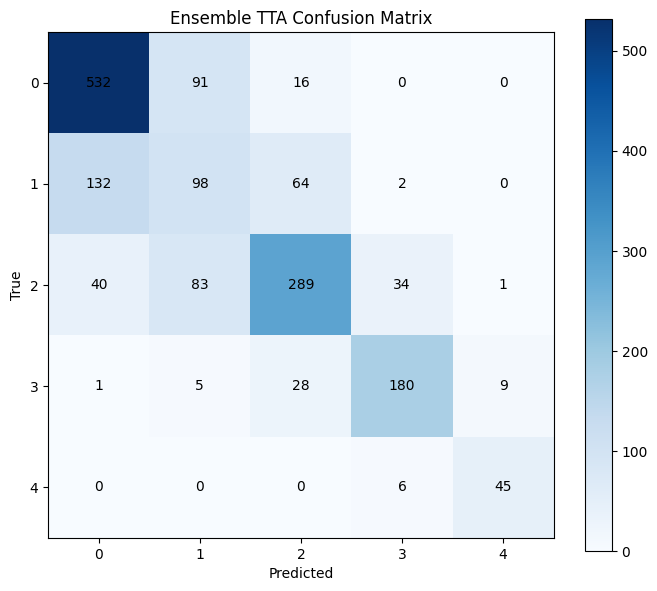

Saved: /content/drive/MyDrive/Knee_OA_Project/experiments/resnet50_ensemble_eval/ensemble_confusion_matrix.png


In [25]:
cm = confusion_matrix(ens_true_tta, ens_pred_tta)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(CLASS_NAMES)
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Ensemble TTA Confusion Matrix")

for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar(im)
plt.tight_layout()
plt.savefig(ENS_CM_PATH, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", ENS_CM_PATH)

In [26]:
pred_df = pd.DataFrame({
    "path": ens_paths_tta,
    "y_true": ens_true_tta,
    "y_pred": ens_pred_tta
})
pred_df["abs_error"] = (pred_df["y_true"] - pred_df["y_pred"]).abs()
pred_df.to_csv(ENS_PRED_PATH, index=False)

print("Saved:", ENS_PRED_PATH)
pred_df.head()

Saved: /content/drive/MyDrive/Knee_OA_Project/experiments/resnet50_ensemble_eval/ensemble_predictions.csv


,path,y_true,y_pred,abs_error
0,/content/kneeoa_data/test/0/9827858L.png,0,0,0
1,/content/kneeoa_data/test/0/9030418R.png,0,0,0
2,/content/kneeoa_data/test/0/9594682R.png,0,0,0
3,/content/kneeoa_data/test/0/9733523L.png,0,0,0
4,/content/kneeoa_data/test/0/9789177L.png,0,0,0


In [27]:
summary_lines = []
summary_lines.append("ResNet50 Ensemble Evaluation")
summary_lines.append("")

summary_lines.append("No TTA metrics:")
for k, v in ens_metrics.items():
    summary_lines.append(f"{k}: {v:.4f}")

summary_lines.append("")
summary_lines.append("With TTA metrics:")
for k, v in ens_metrics_tta.items():
    summary_lines.append(f"{k}: {v:.4f}")

summary_text = "\n".join(summary_lines)

with open(ENS_SUMMARY_PATH, "w") as f:
    f.write(summary_text)

print(summary_text)
print("\nSaved:", ENS_SUMMARY_PATH)

ResNet50 Ensemble Evaluation

No TTA metrics:
accuracy: 0.6908
precision_macro: 0.6915
recall_macro: 0.7037
f1_macro: 0.6963
balanced_accuracy: 0.7037
qwk: 0.8470
pm1_accuracy: 0.9559

With TTA metrics:
accuracy: 0.6908
precision_macro: 0.6931
recall_macro: 0.6999
f1_macro: 0.6953
balanced_accuracy: 0.6999
qwk: 0.8509
pm1_accuracy: 0.9607

Saved: /content/drive/MyDrive/Knee_OA_Project/experiments/resnet50_ensemble_eval/ensemble_summary.txt


In [28]:
val_df = df[df["split"] == "val"].reset_index(drop=True)

val_loader = DataLoader(
    KneeOADataset(val_df),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=pil_collate_fn
)

print("Validation size:", len(val_df))
print("Number of val batches:", len(val_loader))

Validation size: 826
Number of val batches: 26


In [29]:
@torch.no_grad()
def predict_ensemble_logits(model1, model2, loader, tta_transforms=None):
    model1.eval()
    model2.eval()

    all_logits = []
    y_true_all = []
    all_paths = []

    if tta_transforms is None:
        tta_transforms = [("orig", tfm_original)]

    for pil_imgs, labels, paths in tqdm(loader):
        total_logits = None
        n_votes = 0

        for _, tfm in tta_transforms:
            imgs = torch.stack([tfm(img) for img in pil_imgs]).to(DEVICE, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
                logits1 = model1(imgs)
                logits2 = model2(imgs)

            avg_logits_models = (logits1 + logits2) / 2.0

            if total_logits is None:
                total_logits = avg_logits_models
            else:
                total_logits += avg_logits_models

            n_votes += 1

        final_logits = total_logits / n_votes

        all_logits.append(final_logits.cpu().numpy())
        y_true_all.extend(labels.numpy().tolist())
        all_paths.extend(paths)

    all_logits = np.concatenate(all_logits, axis=0)
    return all_logits, np.array(y_true_all), all_paths

In [30]:
val_logits, val_true, val_paths = predict_ensemble_logits(
    model1, model2, val_loader, tta_transforms=[("orig", tfm_original)]
)

test_logits, test_true_logits, test_paths_logits = predict_ensemble_logits(
    model1, model2, test_loader, tta_transforms=[("orig", tfm_original)]
)

print("val_logits shape:", val_logits.shape)
print("test_logits shape:", test_logits.shape)

  0%|          | 0/26 [00:00<?, ?it/s]

  0%|          | 0/52 [00:00<?, ?it/s]

val_logits shape: (826, 5)
test_logits shape: (1656, 5)


In [31]:
val_pred_raw = np.argmax(val_logits, axis=1)
test_pred_raw = np.argmax(test_logits, axis=1)

print("Raw ensemble validation metrics:")
for k, v in compute_metrics(val_true, val_pred_raw).items():
    print(f"{k}: {v:.4f}")

print("\nRaw ensemble test metrics:")
for k, v in compute_metrics(test_true_logits, test_pred_raw).items():
    print(f"{k}: {v:.4f}")

Raw ensemble validation metrics:
accuracy: 0.6659
precision_macro: 0.6815
recall_macro: 0.6988
f1_macro: 0.6892
balanced_accuracy: 0.6988
qwk: 0.8140
pm1_accuracy: 0.9383

Raw ensemble test metrics:
accuracy: 0.6908
precision_macro: 0.6915
recall_macro: 0.7037
f1_macro: 0.6963
balanced_accuracy: 0.7037
qwk: 0.8470
pm1_accuracy: 0.9559


In [32]:
def apply_bias_and_predict(logits, bias):
    return np.argmax(logits + bias[None, :], axis=1)

def score_bias(bias, logits, y_true):
    preds = apply_bias_and_predict(logits, bias)
    metrics = compute_metrics(y_true, preds)
    return metrics

def random_search_bias(val_logits, val_true, n_rounds=3, n_samples_per_round=2500):
    best_bias = np.zeros(val_logits.shape[1], dtype=np.float32)
    best_metrics = score_bias(best_bias, val_logits, val_true)
    best_acc = best_metrics["accuracy"]
    best_f1 = best_metrics["f1_macro"]

    print("Start bias:", best_bias)
    print("Start val accuracy:", best_acc)
    print("Start val macro F1:", best_f1)

    scales = [0.50, 0.20, 0.08]

    for rnd, scale in enumerate(scales[:n_rounds], start=1):
        print(f"\nRound {rnd} | scale={scale}")
        for _ in range(n_samples_per_round):
            candidate = best_bias + np.random.normal(loc=0.0, scale=scale, size=5).astype(np.float32)
            candidate = candidate - candidate.mean()   # remove global shift

            metrics = score_bias(candidate, val_logits, val_true)
            acc = metrics["accuracy"]
            f1 = metrics["f1_macro"]

            if (acc > best_acc) or (acc == best_acc and f1 > best_f1):
                best_bias = candidate
                best_acc = acc
                best_f1 = f1
                best_metrics = metrics

        print("Current best bias:", np.round(best_bias, 4))
        print("Current best val accuracy:", round(best_acc, 4))
        print("Current best val macro F1:", round(best_f1, 4))

    return best_bias, best_metrics

In [33]:
best_bias, best_val_metrics_biased = random_search_bias(
    val_logits, val_true,
    n_rounds=3,
    n_samples_per_round=2500
)

print("\nBest bias found:")
print(np.round(best_bias, 4))

print("\nBest biased validation metrics:")
for k, v in best_val_metrics_biased.items():
    print(f"{k}: {v:.4f}")

Start bias: [0. 0. 0. 0. 0.]
Start val accuracy: 0.6658595641646489
Start val macro F1: 0.6891965601077582

Round 1 | scale=0.5
Current best bias: [ 0.6217 -1.0374  0.0348  0.1242  0.2567]
Current best val accuracy: 0.6913
Current best val macro F1: 0.6657

Round 2 | scale=0.2
Current best bias: [ 0.5467 -0.8046 -0.0117  0.1321  0.1374]
Current best val accuracy: 0.6913
Current best val macro F1: 0.6757

Round 3 | scale=0.08
Current best bias: [ 0.6045 -0.7657  0.0023  0.0936  0.0653]
Current best val accuracy: 0.6913
Current best val macro F1: 0.6758

Best bias found:
[ 0.6045 -0.7657  0.0023  0.0936  0.0653]

Best biased validation metrics:
accuracy: 0.6913
precision_macro: 0.6904
recall_macro: 0.6962
f1_macro: 0.6758
balanced_accuracy: 0.6962
qwk: 0.8141
pm1_accuracy: 0.9237


In [34]:
test_pred_biased = apply_bias_and_predict(test_logits, best_bias)
test_metrics_biased = compute_metrics(test_true_logits, test_pred_biased)

print("Biased ensemble test metrics:")
for k, v in test_metrics_biased.items():
    print(f"{k}: {v:.4f}")

Biased ensemble test metrics:
accuracy: 0.7023
precision_macro: 0.6856
recall_macro: 0.6914
f1_macro: 0.6722
balanced_accuracy: 0.6914
qwk: 0.8375
pm1_accuracy: 0.9360


In [35]:
print(classification_report(test_true_logits, test_pred_biased, digits=4))

              precision    recall  f1-score   support

           0     0.7002    0.9249    0.7970       639
           1     0.4095    0.1453    0.2145       296
           2     0.7146    0.6779    0.6958       447
           3     0.7965    0.8072    0.8018       223
           4     0.8070    0.9020    0.8519        51

    accuracy                         0.7023      1656
   macro avg     0.6856    0.6914    0.6722      1656
weighted avg     0.6684    0.7023    0.6679      1656



In [36]:
biased_pred_df = pd.DataFrame({
    "path": test_paths_logits,
    "y_true": test_true_logits,
    "y_pred": test_pred_biased
})
biased_pred_df["abs_error"] = (biased_pred_df["y_true"] - biased_pred_df["y_pred"]).abs()

BIASED_PRED_PATH = ENSEMBLE_DIR / "ensemble_biased_predictions.csv"
biased_pred_df.to_csv(BIASED_PRED_PATH, index=False)

print("Saved:", BIASED_PRED_PATH)
biased_pred_df.head()

Saved: /content/drive/MyDrive/Knee_OA_Project/experiments/resnet50_ensemble_eval/ensemble_biased_predictions.csv


,path,y_true,y_pred,abs_error
0,/content/kneeoa_data/test/0/9827858L.png,0,0,0
1,/content/kneeoa_data/test/0/9030418R.png,0,0,0
2,/content/kneeoa_data/test/0/9594682R.png,0,0,0
3,/content/kneeoa_data/test/0/9733523L.png,0,0,0
4,/content/kneeoa_data/test/0/9789177L.png,0,0,0
